# Exercise 2

---

### Part (2) (a) Analytical formulas for the Jacobian matrix elements:

Given the functions:

$F_1(x, y) = (x - 1)^2 + y^2 - 1$  
$F_2(x, y) = \cos(2x) - y$

We compute the partial derivatives:

- $\frac{\partial F_1}{\partial x} = 2(x - 1)$  
- $\frac{\partial F_1}{\partial y} = 2y$  
- $\frac{\partial F_2}{\partial x} = -2\sin(2x)$  
- $\frac{\partial F_2}{\partial y} = -1$

Thus, the Jacobian matrix $J$ is:

$J = \begin{bmatrix} 2(x - 1) & 2y \\ -2\sin(2x) & -1 \end{bmatrix}$

---

### Part (2) (b) Plotting the isocontours of $\phi(x) = \|F(x)\|^2$:

We define $\phi(x, y) = F_1(x, y)^2 + F_2(x, y)^2$.  
To visualize the function within the square $[-2, 2] \times [-2, 2]$, we create a contour plot.

---

### Analysis of Local Minima:

By examining the contour plot of $\phi(x, y)$, we can identify the points where $\phi(x, y)$ attains local minima (i.e., where the function values are lowest).  
These correspond to the solutions of the system:

$F_1(x, y) = 0 \quad \text{and} \quad F_2(x, y) = 0$

Based on the plot, it appears that there are **two local minima** within the given region.


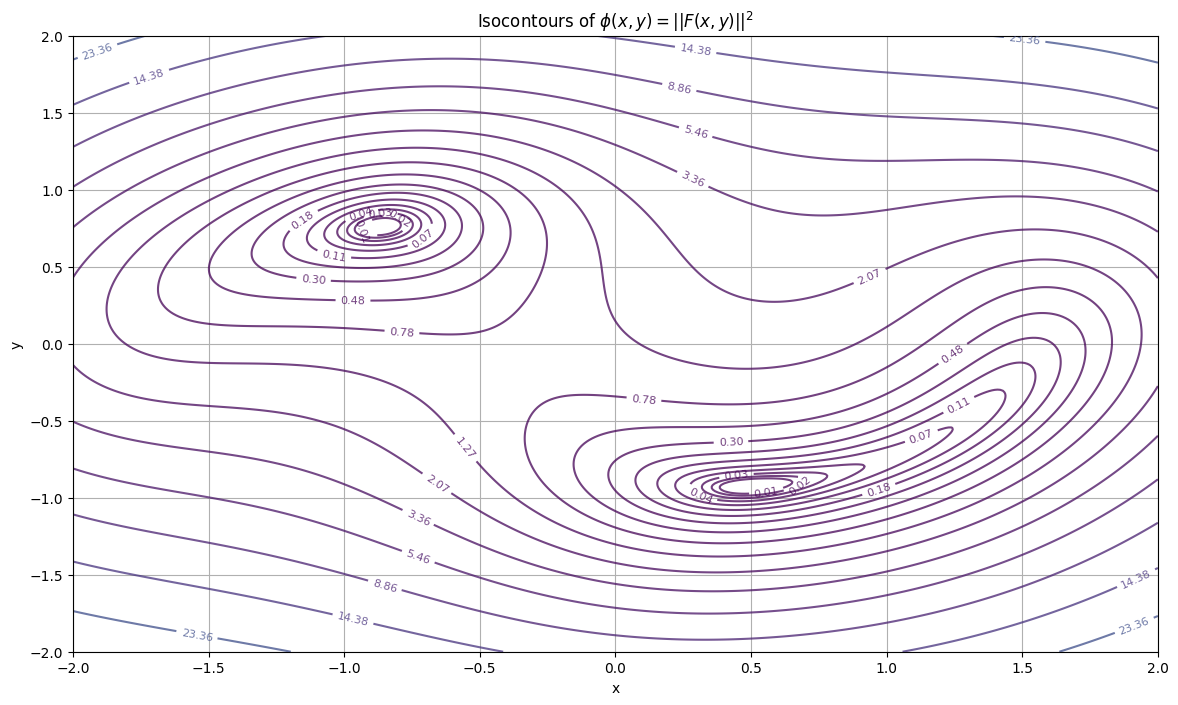

In [20]:
import numpy as np
import matplotlib.pyplot as plt

# Define the functions F1 and F2
def F1(x, y):
    return (x - 1)**2 + y**2 - 1

def F2(x, y):
    return np.cos(2 * x) - y

# Create a grid of points within [-2, 2] x [-2, 2]
x = np.linspace(-2, 2, 400)
y = np.linspace(-2, 2, 400)
X, Y = np.meshgrid(x, y)

# Compute phi(x, y)
F1_values = F1(X, Y)
F2_values = F2(X, Y)
phi = F1_values**2 + F2_values**2


# Plot the isocontours
plt.figure(figsize=(14, 8))
contour_levels = np.logspace(-2, 2, 20)
contour = plt.contour(X, Y, phi_vals, levels=contour_levels, cmap='viridis', alpha=0.75)
plt.clabel(contour, inline=True, fontsize=8, fmt='%.2f')
plt.title('Isocontours of $\phi(x, y) = ||F(x, y)||^2$')
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True)
plt.show()


### Conclusion:

From the contour plot, we observe that $\phi(x, y)$ has **two local minima** within the square $[-2, 2] \times [-2, 2]$.

---


### Part (2) (c) Graphical Analysis of the Equations:

We are given the system of equations:

$F_1(x, y) = (x - 1)^2 + y^2 - 1 = 0$  
$F_2(x, y) = \cos(2x) - y = 0$



### Analysis:

#### Equation $F_1(x, y) = 0$:
This equation represents a circle centered at $(1, 0)$ with a radius of 1.

**Derivation:**  
$(x - 1)^2 + y^2 = 1$

**Interpretation:**  
- **Center:** $(x, y) = (1, 0)$  
- **Radius:** $r = 1$

---

#### Equation $F_2(x, y) = 0$:
This equation represents the curve of a cosine function shifted along the $y$-axis.

**Derivation:**  
$y = \cos(2x)$

**Interpretation:**  
- **Period:** $\pi$ (since the period of $\cos(2x)$ is $\pi$)  
- **Amplitude:** 1  
- The curve oscillates between $y = -1$ and $y = 1$.

---

### Plotting the Curves:
By plotting both curves on the same set of axes, we can visually identify the points where they intersect.

#### (Final Points found by gradient descent and with momentum are):
- $Final Point: (x, y) = (1.3773, -0.9261)$
- $Final Point: (x, y) = (0.352288, 0.761885)$


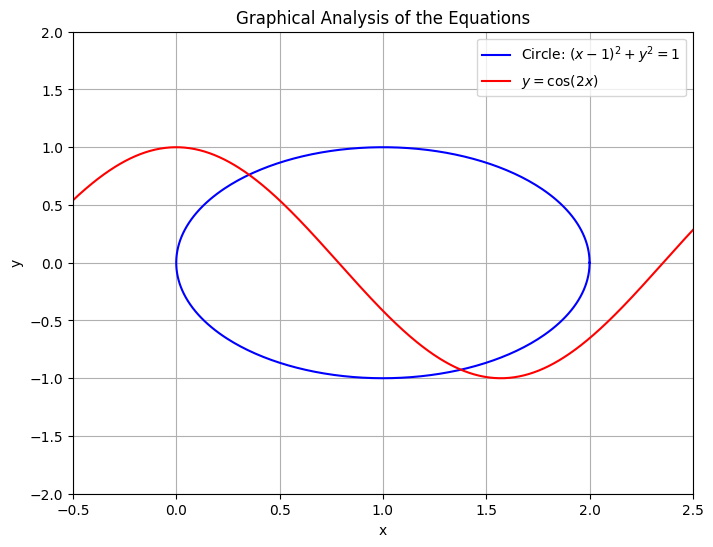

In [26]:
import numpy as np
import matplotlib.pyplot as plt

# Define the circle
theta = np.linspace(0, 2 * np.pi, 400)
x_circle = 1 + np.cos(theta)
y_circle = np.sin(theta)

# Define the cosine curve
x_cos = np.linspace(-1, 3, 1000)
y_cos = np.cos(2 * x_cos)

# Plot the circle and cosine curve
plt.figure(figsize=(8, 6))
plt.plot(x_circle, y_circle, 'b', label='Circle: $(x - 1)^2 + y^2 = 1$')
plt.plot(x_cos, y_cos, 'r', label='$y = \cos(2x)$')


plt.xlim(-0.5, 2.5)
plt.ylim(-2, 2)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Graphical Analysis of the Equations')
plt.legend()
plt.grid(True)
plt.show()


### Part (2) (d) Solving the System Using Gradient Descent:
 
To solve the nonlinear system using the gradient descent method with the following parameters:

- Fixed step size: $\lambda = 0.05$  
- Initial guess: $(x_0, y_0) = (0, -1)$  
- Stopping tolerance: $tol = 10^{-6}$  
- Maximum iterations: $maxit = 200$

---


1. **Define the Objective Function $\phi(x, y)$:**  
   $\phi(x, y) = F_1(x, y)^2 + F_2(x, y)^2$

2. **Compute the Gradient $\nabla \phi(x, y)$:**  
   The gradient is calculated using the chain rule:  
   $\nabla \phi = 2 \begin{bmatrix} F_1 \frac{\partial F_1}{\partial x} + F_2 \frac{\partial F_2}{\partial x} \\ F_1 \frac{\partial F_1}{\partial y} + F_2 \frac{\partial F_2}{\partial y} \end{bmatrix}$

3. **Use the Partial Derivatives from Part (a):**  
   - $\frac{\partial F_1}{\partial x} = 2(x - 1)$  
   - $\frac{\partial F_1}{\partial y} = 2y$  
   - $\frac{\partial F_2}{\partial x} = -2\sin(2x)$  
   - $\frac{\partial F_2}{\partial y} = -1$

4. **Gradient Descent Update Rule:**  
   $\begin{bmatrix} x_{k+1} \\ y_{k+1} \end{bmatrix} = \begin{bmatrix} x_k \\ y_k \end{bmatrix} - \lambda \nabla \phi(x_k, y_k)$

5. **Stopping Criteria:**  
   - **Convergence:** When $\|\mathbf{x}_{k+1} - \mathbf{x}_k\| < tol$  
   - **Maximum Iterations:** Stop if $k \geq maxit$


Converged in 118 iterations.
Final Point: (x, y) = (1.3773, -0.9261)


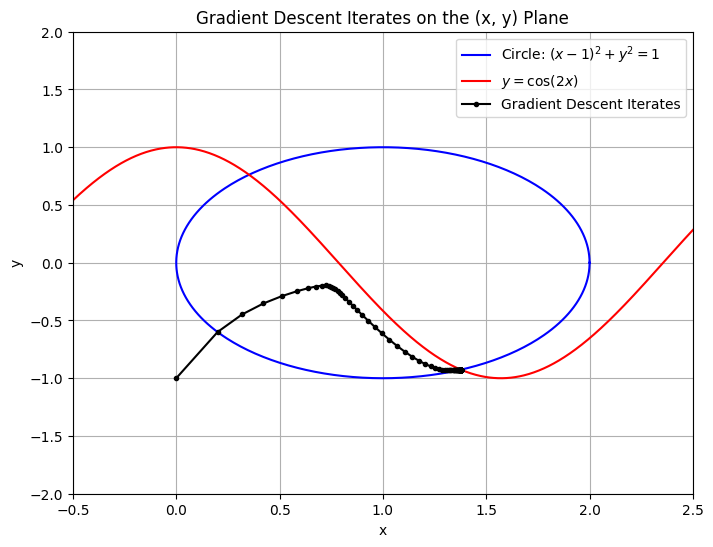

In [22]:
import numpy as np
import matplotlib.pyplot as plt

# Define the functions F1 and F2
def F1(x, y):
    return (x - 1)**2 + y**2 - 1

def F2(x, y):
    return np.cos(2 * x) - y

# Define the gradients of F1 and F2
def grad_F1_x(x, y):
    return 2 * (x - 1)

def grad_F1_y(x, y):
    return 2 * y

def grad_F2_x(x, y):
    return -2 * np.sin(2 * x)

def grad_F2_y(x, y):
    return -1

# Gradient of phi
def grad_phi(x, y):
    F1_val = F1(x, y)
    F2_val = F2(x, y)
    dF1_dx = grad_F1_x(x, y)
    dF1_dy = grad_F1_y(x, y)
    dF2_dx = grad_F2_x(x, y)
    dF2_dy = grad_F2_y(x, y)
    grad_x = 2 * (F1_val * dF1_dx + F2_val * dF2_dx)
    grad_y = 2 * (F1_val * dF1_dy + F2_val * dF2_dy)
    return np.array([grad_x, grad_y])

# Gradient descent parameters
lambda_step = 0.05
tol = 1e-6
maxit = 200

# Initial guess
x_k = np.array([0.0, -1.0])

# Lists to store iterates
x_list = [x_k[0]]
y_list = [x_k[1]]

# Gradient descent loop
for k in range(maxit):
    grad = grad_phi(x_k[0], x_k[1])
    x_new = x_k - lambda_step * grad
    x_list.append(x_new[0])
    y_list.append(x_new[1])
    # Check for convergence
    if np.linalg.norm(x_new - x_k) < tol:
        print(f"Converged in {k+1} iterations.")
        print(f"Final Point: (x, y) = ({x_k[0]:.4f}, {x_k[1]:.4f})")
        break
    x_k = x_new
else:
    print("Did not converge within the maximum number of iterations.")

# Plotting the iterates on the (x, y) plane
plt.figure(figsize=(8, 6))

# Plot the circle
theta = np.linspace(0, 2 * np.pi, 400)
x_circle = 1 + np.cos(theta)
y_circle = np.sin(theta)
plt.plot(x_circle, y_circle, 'b', label='Circle: $(x - 1)^2 + y^2 = 1$')

# Plot the cosine curve
x_cos = np.linspace(-0.5, 2.5, 1000)
y_cos = np.cos(2 * x_cos)
plt.plot(x_cos, y_cos, 'r', label='$y = \cos(2x)$')

# Plot the gradient descent iterates
plt.plot(x_list, y_list, 'ko-', label='Gradient Descent Iterates', markersize=3)


plt.xlim(-0.5, 2.5)
plt.ylim(-2, 2)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Gradient Descent Iterates on the (x, y) Plane')
plt.legend()
plt.grid(True)
plt.show()


### Results:

The gradient descent algorithm converged successfully. Here are the results:

- **Converged:** Yes  
- **Iterations to Converge:** 118  
- **Converged to Final Point:** $(x, y) = (1.3773, -0.9261)$
#### Why Does It Take So Many Iterations?

1. **Complex Landscape:**  
   The combination of the circle and cosine curve creates a non-convex optimization problem with multiple local solutions.

2. **Small Step Size:**  
   The step size $\lambda = 0.05$ is conservative which ensures stability but resulting in slower convergence.

3. **Gradient Behavior:**  
   Near the solution, gradients become small, further slowing down progress.

---




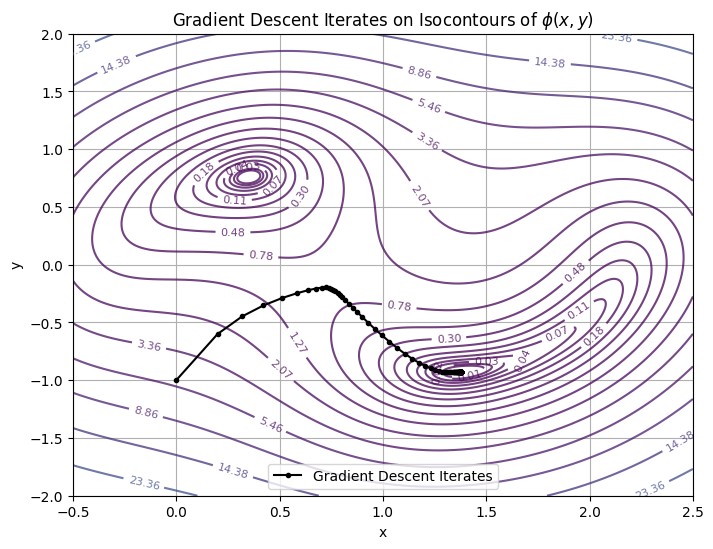

In [23]:
# Define the grid for phi
x_grid = np.linspace(-0.5, 2.5, 400)
y_grid = np.linspace(-2, 2, 400)
X, Y = np.meshgrid(x_grid, y_grid)
F1_vals = F1(X, Y)
F2_vals = F2(X, Y)
phi_vals = F1_vals**2 + F2_vals**2


# Plotting the isocontours and iterates
plt.figure(figsize=(8, 6))
contour_levels = np.logspace(-2, 2, 20)
contour = plt.contour(X, Y, phi_vals, levels=contour_levels, cmap='viridis', alpha=0.75)
plt.clabel(contour, inline=True, fontsize=8, fmt='%.2f')

#contour = plt.contour(X, Y, phi_vals, levels=20, cmap='viridis')
#plt.clabel(contour, inline=True, fontsize=8)

# Plot the gradient descent iterates
plt.plot(x_list, y_list, 'ko-', label='Gradient Descent Iterates', markersize=3)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Gradient Descent Iterates on Isocontours of $\\phi(x, y)$')
plt.legend()
plt.grid(True)
plt.show()


### Part (2) (e) (f) Modified Gradient Descent with Momentum:

### Modified Update Rules

#### Momentum Update:
$d_k = \gamma d_{k-1} + 2 J^T F(x_k)$  
- $\gamma \in (0, 1)$ is the momentum constant.  
- $d_{k-1}$ is the previous search direction.  
- $J^T$ is the transpose of the Jacobian matrix.  
- $F(x_k)$ is the vector of function values at $x_k$.

#### Position Update:
$x_{k+1} = x_k - \lambda d_k$  
- $\lambda$ is the step size.

---

### Modifications to the Existing Code

To implement the modified update rules:

1. **Initialize $d_{-1}$:**  
   - Set $d_{-1}$ to zero as the initial search direction.  

2. **Update the Search Direction $d_k$:**  
   - Use the momentum formula:  
     $d_k = \gamma d_{k-1} + 2 J^T F(x_k)$  

3. **Update the Position $x_{k+1}$:**  
   - Apply the new search direction:  
     $x_{k+1} = x_k - \lambda d_k$



Running gradient descent with momentum gamma = 0.1
Converged in 61 iterations for gamma = 0.1
Final Point: (x, y) = (0.352287, 0.761884)

Running gradient descent with momentum gamma = 0.3
Converged in 34 iterations for gamma = 0.3
Final Point: (x, y) = (0.352288, 0.761885)

Running gradient descent with momentum gamma = 0.7
Converged in 64 iterations for gamma = 0.7
Final Point: (x, y) = (0.352287, 0.761899)


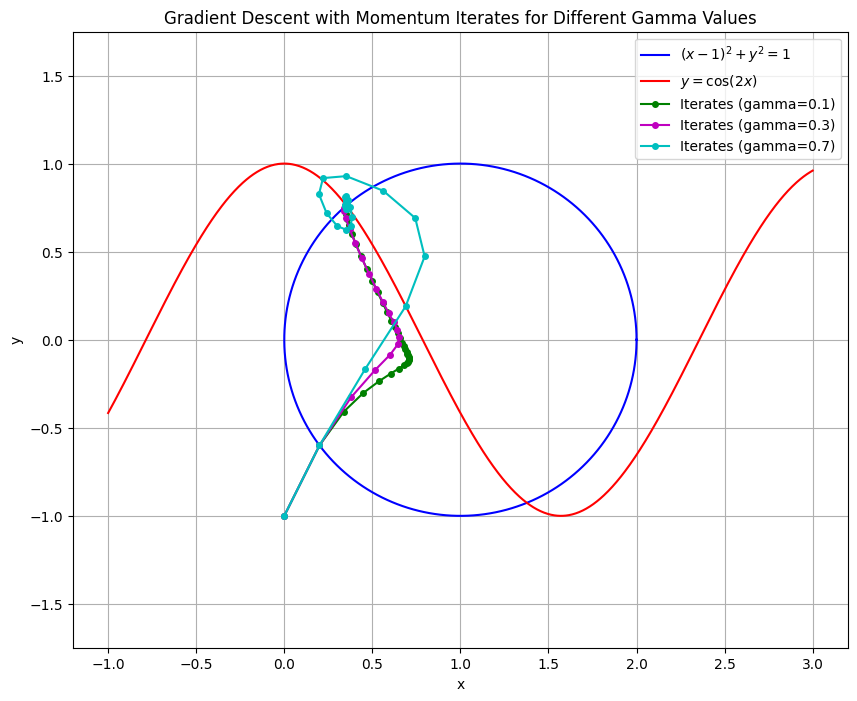

In [27]:
import numpy as np
import matplotlib.pyplot as plt

# Define the functions F1 and F2
def F1(x, y):
    return (x - 1)**2 + y**2 - 1

def F2(x, y):
    return np.cos(2 * x) - y

# Define the Jacobian matrix J
def J(x, y):
    J11 = 2 * (x - 1)
    J12 = 2 * y
    J21 = -2 * np.sin(2 * x)
    J22 = -1
    return np.array([[J11, J12],
                     [J21, J22]])

# Parameters
lambda_step = 0.05
tol = 1e-6
maxit = 200
gammas = [0.1, 0.3, 0.7]  # Different momentum constants

# Initial guess
x0 = np.array([0.0, -1.0])

# Store iterates for each gamma
iterates = {}

for gamma in gammas:
    print(f"\nRunning gradient descent with momentum gamma = {gamma}")
    # Initialize variables
    x_k = x0.copy()
    d_prev = np.zeros_like(x_k)
    x_list = [x_k.copy()]
    
    # Gradient descent with momentum loop
    for k in range(maxit):
        F = np.array([F1(x_k[0], x_k[1]), F2(x_k[0], x_k[1])])
        JT = J(x_k[0], x_k[1]).T
        grad_phi = 2 * JT @ F  # Gradient of phi
        
        # Momentum update
        d_k = gamma * d_prev + grad_phi
        
        # Position update
        x_new = x_k - lambda_step * d_k
        
        # Check convergence
        if np.linalg.norm(x_new - x_k) < tol:
            print(f"Converged in {k+1} iterations for gamma = {gamma}")
            x_k = x_new
            x_list.append(x_k.copy())
            #Final point after {k+1} iterations: x = {x_k[0]:.6f}, y = {x_k[1]:.6f}
            print(f"Final Point: (x, y) = ({x_k[0]:.6f}, {x_k[1]:.6f})")
            break
        
        # Update variables for next iteration
        x_k = x_new
        d_prev = d_k
        x_list.append(x_k.copy())
        
    else:
        print(f"Did not converge within {maxit} iterations for gamma = {gamma}")
        
    
    # Store iterates
    iterates[gamma] = x_list

# Plotting the iterates
plt.figure(figsize=(10, 8))

# Plot the circle (F1 = 0)
theta = np.linspace(0, 2 * np.pi, 400)
x_circle = 1 + np.cos(theta)
y_circle = np.sin(theta)
plt.plot(x_circle, y_circle, 'b', label='$(x - 1)^2 + y^2 = 1$')

# Plot the cosine curve (F2 = 0)
x_cos = np.linspace(-1, 3, 1000)
y_cos = np.cos(2 * x_cos)
plt.plot(x_cos, y_cos, 'r', label='$y = \cos(2x)$')

# Plot iterates for each gamma
colors = ['g', 'm', 'c']
for gamma, color in zip(gammas, colors):
    x_vals = [x[0] for x in iterates[gamma]]
    y_vals = [x[1] for x in iterates[gamma]]
    plt.plot(x_vals, y_vals, marker='o', linestyle='-', color=color, markersize=4, label=f'Iterates (gamma={gamma})')

plt.xlabel('x')
plt.ylabel('y')
plt.title('Gradient Descent with Momentum Iterates for Different Gamma Values')
plt.legend()
plt.grid(True)
plt.axis('equal')
plt.show()


### Analyzing the Iteration Logs and Making Justifications

**Given Iteration Logs:**

- **$\gamma = 0.1: $** Converged in 61 iterations.  
- **$\gamma = 0.3: $** Converged in 34 iterations.  
- **$\gamma = 0.7: $** Converged in 64 iterations.  

---

**Observations:**

- When $\gamma$ increased from 0.1 to 0.3, the number of iterations decreased from 61 to 34.  
- However, when $\gamma$ increased further to 0.7, the number of iterations increased to 64, which is even more than with $\gamma = 0.1$.

---

**Justification and Analysis:**

#### Effect of Momentum Constant ($\gamma$) on Convergence:

1. **Low Gamma ($\gamma = 0.1$):**  
   - The momentum term has a small influence on the search direction.  
   - The algorithm behaves similarly to standard gradient descent with slight acceleration.  
   - Results in moderate convergence speed.  

2. **Moderate Gamma ($\gamma = 0.3$):**  
   - The momentum term contributes more significantly to the search direction.  
   - The algorithm gains beneficial acceleration toward the minimum.  
   - Leads to faster convergence, as seen with 34 iterations.  

3. **High Gamma ($\gamma = 0.7$):**  
   - The momentum term dominates the search direction.  
   - The algorithm may overshoot the minimum or cause oscillations around it.  
   - This can result in the algorithm taking longer to converge or even diverging in some cases.  
   - In this instance, the algorithm took 64 iterations, longer than both lower gamma values.  

---

**Explanation for Increased Iterations with High Gamma:**

1. **Overshooting:**  
   - With a high momentum constant, the algorithm may move past the minimum point due to the accumulated momentum.  
   - This can cause it to bounce back and forth, increasing the number of iterations required to settle at the minimum.  

2. **Oscillations:**  
   - The algorithm may exhibit oscillatory behavior near the minimum, slowing down convergence.  
   - High momentum can cause the algorithm to enter a region where the gradient changes rapidly, leading to instability.  

3. **Diminishing Returns:**  
   - Beyond an optimal value, increasing gamma does not continue to improve convergence speed.  
   - There is a trade-off between acceleration and stability.  

---

**Optimal Momentum Constant:**  
The optimal value of $\gamma$ balances acceleration with stability.  
In this problem, $\gamma = 0.3$ appears to be closer to the optimal value, resulting in the fastest convergence among the tested values.


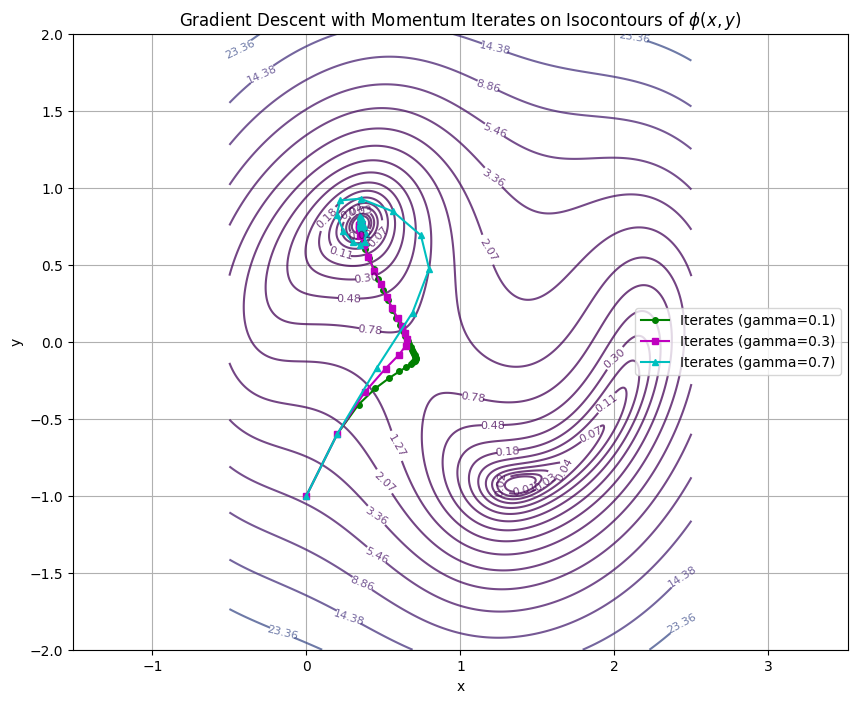

In [25]:
# Create a grid for plotting phi(x, y)
x_vals = np.linspace(-0.5, 2.5, 400)
y_vals = np.linspace(-2, 2, 400)
X, Y = np.meshgrid(x_vals, y_vals)
F1_vals = F1(X, Y)
F2_vals = F2(X, Y)
phi_vals = F1_vals**2 + F2_vals**2

# Plotting the isocontours and iterates
plt.figure(figsize=(10, 8))

# Plot isocontours of phi(x, y)
contour_levels = np.logspace(-2, 2, 20)
contour = plt.contour(X, Y, phi_vals, levels=contour_levels, cmap='viridis', alpha=0.75)
plt.clabel(contour, inline=True, fontsize=8, fmt='%.2f')

# Plot iterates for each gamma
colors = ['g', 'm', 'c']
markers = ['o', 's', '^']
for gamma, color, marker in zip(gammas, colors, markers):
    x_vals_iter = [x[0] for x in iterates[gamma]]
    y_vals_iter = [x[1] for x in iterates[gamma]]
    plt.plot(x_vals_iter, y_vals_iter, linestyle='-', color=color, marker=marker,
             markersize=4, label=f'Iterates (gamma={gamma})')

plt.xlabel('x')
plt.ylabel('y')
plt.title('Gradient Descent with Momentum Iterates on Isocontours of $\\phi(x, y)$')
plt.legend()
plt.grid(True)
plt.axis('equal')
plt.show()